# Guard-Bed Pretreatment Dataset Builder

This notebook contains the full PSA pretreatment guard-bed simulator and dataset builder.

Rules used in this notebook:
- Keep the existing feature and target variables.
- Save only one file: `test.csv`.
- Show sanity-check tables and plots only inside the notebook output.
- Generate `100` scenarios for sequence-model training.

Physics used here:
- 1D axial packed-bed transport model.
- PM and mist deposition with blockage growth.
- Liquid holdup, drainage, and humidity-driven condensation source.
- Ergun pressure-drop model with porosity and particle sphericity effects.
- Axial pressure marching so local density and superficial velocity change along the bed.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import qmc

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

BASE_DIR = Path.cwd()
OUTPUT_CSV = BASE_DIR / 'test.csv'

R = 8.314462618
SECONDS_PER_HOUR = 3600.0
ATM = 101_325.0

MW = {
    'CO2': 44.0095e-3,
    'N2': 28.0134e-3,
    'O2': 31.9988e-3,
    'H2O': 18.01528e-3,
}

PURE_VISCOSITY_PA_S = {
    'CO2': 1.48e-5,
    'N2': 1.76e-5,
    'O2': 2.05e-5,
    'H2O': 1.10e-5,
}


def clamp(value: float, lower: float, upper: float) -> float:
    return max(lower, min(upper, value))


def saturation_pressure_water_pa(temperature_c: float) -> float:
    a, b, c = 8.07131, 1730.63, 233.426
    p_mmHg = 10 ** (a - b / (c + temperature_c))
    return p_mmHg * 133.322368


def composition_from_humidity(
    temperature_c: float,
    pressure_pa: float,
    relative_humidity: float,
    y_co2: float,
    y_o2: float,
) -> Dict[str, float]:
    y_h2o = clamp(relative_humidity * saturation_pressure_water_pa(temperature_c) / pressure_pa, 1e-6, 0.18)
    y_n2 = 1.0 - (y_co2 + y_o2 + y_h2o)
    if y_n2 <= 0.0:
        raise ValueError('Invalid gas composition from humidity inputs.')
    return {'CO2': y_co2, 'N2': y_n2, 'O2': y_o2, 'H2O': y_h2o}


def mixture_mw(y: Dict[str, float]) -> float:
    return sum(y[k] * MW[k] for k in MW)


def wilke_mixture_viscosity(y: Dict[str, float], temperature_c: float) -> float:
    temp_factor = (temperature_c + 273.15) / 298.15
    mu_species = {sp: PURE_VISCOSITY_PA_S[sp] * temp_factor ** 0.7 for sp in MW}
    numerator = 0.0
    species = tuple(MW.keys())
    for i in species:
        yi = y[i]
        if yi <= 0.0:
            continue
        denom = 0.0
        for j in species:
            phi_ij = (
                (1.0 + (mu_species[i] / mu_species[j]) ** 0.5 * (MW[j] / MW[i]) ** 0.25) ** 2
                / (8.0 * (1.0 + MW[i] / MW[j])) ** 0.5
            )
            denom += y[j] * phi_ij
        numerator += yi * mu_species[i] / max(denom, 1e-12)
    return max(numerator, 1e-6)


def gas_density_kg_m3(pressure_pa: float, temperature_c: float, y: Dict[str, float]) -> float:
    return pressure_pa * mixture_mw(y) / (R * (temperature_c + 273.15))


def hydraulic_diameter_packed_bed(particle_diameter_m: float, porosity: float) -> float:
    return 2.0 / 3.0 * particle_diameter_m * porosity / max(1.0 - porosity, 1e-9)


def ergun_gradient_pa_m(
    rho: float,
    mu: float,
    superficial_velocity: float,
    particle_diameter_m: float,
    porosity: float,
    particle_sphericity: float,
) -> float:
    eps = clamp(porosity, 0.12, 0.75)
    dp = max(particle_diameter_m, 1e-5)
    phi = clamp(particle_sphericity, 0.35, 1.0)
    viscous = 150.0 * (1.0 - eps) ** 2 / (eps ** 3 * phi ** 2) * mu * superficial_velocity / dp ** 2
    inertial = 1.75 * (1.0 - eps) / (eps ** 3 * phi) * rho * superficial_velocity ** 2 / dp
    return viscous + inertial


@dataclass
class ParameterSpec:
    name: str
    lower: float
    upper: float

    def scale(self, value_01: float) -> float:
        return self.lower + value_01 * (self.upper - self.lower)


@dataclass
class Scenario:
    bed_length_m: float
    bed_diameter_m: float
    particle_diameter_m: float
    bed_porosity: float
    particle_sphericity: float
    flow_mol_s: float
    temperature_c: float
    pressure_in_pa: float
    y_co2: float
    y_o2: float
    relative_humidity: float
    pm_inlet_mg_m3: float
    mist_inlet_mg_m3: float
    operating_time_h0: float
    filter_age_h: float
    cleaning_count: int
    time_since_last_cleaning_h: float
    cleaning_interval_h: float
    pulse_intensity: float
    drainage_rate_1_h: float
    pm_capture_coeff_1_s: float
    mist_capture_coeff_1_s: float
    humidification_factor: float
    compressibility_factor: float
    cells: int = 48

    @property
    def area_m2(self) -> float:
        return math.pi * (self.bed_diameter_m ** 2) / 4.0


def make_default_scenario() -> Scenario:
    return Scenario(
        bed_length_m=1.4,
        bed_diameter_m=2.8,
        particle_diameter_m=0.0105,
        bed_porosity=0.41,
        particle_sphericity=0.92,
        flow_mol_s=620.0,
        temperature_c=38.0,
        pressure_in_pa=ATM,
        y_co2=0.18,
        y_o2=0.04,
        relative_humidity=0.82,
        pm_inlet_mg_m3=22.0,
        mist_inlet_mg_m3=6.0,
        operating_time_h0=0.0,
        filter_age_h=72.0,
        cleaning_count=3,
        time_since_last_cleaning_h=2.0,
        cleaning_interval_h=6.0,
        pulse_intensity=0.32,
        drainage_rate_1_h=0.18,
        pm_capture_coeff_1_s=0.0035,
        mist_capture_coeff_1_s=0.0025,
        humidification_factor=1.0,
        compressibility_factor=1.0,
    )


def parameter_space() -> List[ParameterSpec]:
    return [
        ParameterSpec('bed_length_m', 1.1, 1.9),
        ParameterSpec('bed_diameter_m', 2.1, 3.4),
        ParameterSpec('particle_diameter_m', 0.0080, 0.0130),
        ParameterSpec('bed_porosity', 0.37, 0.45),
        ParameterSpec('particle_sphericity', 0.82, 0.98),
        ParameterSpec('flow_mol_s', 420.0, 760.0),
        ParameterSpec('temperature_c', 28.0, 52.0),
        ParameterSpec('pressure_in_kpa', 98.0, 112.0),
        ParameterSpec('y_co2', 0.14, 0.21),
        ParameterSpec('y_o2', 0.03, 0.05),
        ParameterSpec('relative_humidity', 0.55, 0.98),
        ParameterSpec('pm_inlet_mg_m3', 8.0, 42.0),
        ParameterSpec('mist_inlet_mg_m3', 1.0, 18.0),
        ParameterSpec('filter_age_h', 0.0, 240.0),
        ParameterSpec('cleaning_count', 0.0, 10.0),
        ParameterSpec('time_since_last_cleaning_h', 0.0, 8.0),
        ParameterSpec('cleaning_interval_h', 4.0, 12.0),
        ParameterSpec('pulse_intensity', 0.15, 0.50),
        ParameterSpec('drainage_rate_1_h', 0.08, 0.40),
        ParameterSpec('pm_capture_coeff_1_s', 0.0010, 0.0080),
        ParameterSpec('mist_capture_coeff_1_s', 0.0008, 0.0060),
        ParameterSpec('humidification_factor', 0.9, 1.1),
        ParameterSpec('compressibility_factor', 0.96, 1.02),
    ]


def lhs_samples(n_samples: int, seed: int = 42) -> pd.DataFrame:
    specs = parameter_space()
    sampler = qmc.LatinHypercube(d=len(specs), seed=seed)
    sample_cube = sampler.random(n=n_samples)
    data = {
        spec.name: [spec.scale(sample_cube[i, j]) for i in range(n_samples)]
        for j, spec in enumerate(specs)
    }
    return pd.DataFrame(data)


def build_scenario(record: Dict[str, float]) -> Scenario:
    return Scenario(
        bed_length_m=record['bed_length_m'],
        bed_diameter_m=record['bed_diameter_m'],
        particle_diameter_m=record['particle_diameter_m'],
        bed_porosity=record['bed_porosity'],
        particle_sphericity=record['particle_sphericity'],
        flow_mol_s=record['flow_mol_s'],
        temperature_c=record['temperature_c'],
        pressure_in_pa=record['pressure_in_kpa'] * 1000.0,
        y_co2=record['y_co2'],
        y_o2=record['y_o2'],
        relative_humidity=record['relative_humidity'],
        pm_inlet_mg_m3=record['pm_inlet_mg_m3'],
        mist_inlet_mg_m3=record['mist_inlet_mg_m3'],
        operating_time_h0=0.0,
        filter_age_h=record['filter_age_h'],
        cleaning_count=int(round(record['cleaning_count'])),
        time_since_last_cleaning_h=record['time_since_last_cleaning_h'],
        cleaning_interval_h=record['cleaning_interval_h'],
        pulse_intensity=record['pulse_intensity'],
        drainage_rate_1_h=record['drainage_rate_1_h'],
        pm_capture_coeff_1_s=record['pm_capture_coeff_1_s'],
        mist_capture_coeff_1_s=record['mist_capture_coeff_1_s'],
        humidification_factor=record['humidification_factor'],
        compressibility_factor=record['compressibility_factor'],
    )


def validate_scenario(s: Scenario) -> Tuple[bool, str]:
    try:
        y = composition_from_humidity(s.temperature_c, s.pressure_in_pa, s.relative_humidity, s.y_co2, s.y_o2)
    except ValueError:
        return False, 'composition_invalid'
    if y['N2'] < 0.50 or y['N2'] > 0.78:
        return False, 'n2_out_of_range'
    if s.time_since_last_cleaning_h > s.cleaning_interval_h:
        return False, 'cleaning_clock_invalid'
    if s.flow_mol_s < 700.0 and s.pm_inlet_mg_m3 > 35.0:
        return False, 'unlikely_low_flow_high_pm'
    if s.relative_humidity > 0.94 and s.mist_inlet_mg_m3 < 1.5:
        return False, 'humid_without_mist'
    return True, 'ok'


def constrained_lhs_samples(n_samples: int, seed: int = 42, oversample_factor: int = 4) -> pd.DataFrame:
    accepted_frames: List[pd.DataFrame] = []
    accepted_count = 0
    round_idx = 0
    while accepted_count < n_samples and round_idx < 25:
        needed = n_samples - accepted_count
        batch_size = max(needed * oversample_factor, needed)
        batch = lhs_samples(batch_size, seed=seed + round_idx)
        mask = []
        reasons = []
        for record in batch.to_dict(orient='records'):
            ok, reason = validate_scenario(build_scenario(record))
            mask.append(ok)
            reasons.append(reason)
        batch['valid'] = mask
        batch['reject_reason'] = reasons
        accepted = batch[batch['valid']].copy()
        if not accepted.empty:
            accepted_frames.append(accepted)
            accepted_count += len(accepted)
        round_idx += 1
    if accepted_count < n_samples:
        raise RuntimeError(f'Unable to create {n_samples} valid scenarios.')
    out = pd.concat(accepted_frames, ignore_index=True).iloc[:n_samples].copy()
    out.drop(columns=['valid'], inplace=True)
    return out


class GuardBedSimulator:
    def __init__(self, scenario: Scenario):
        self.scenario = scenario
        self.n = scenario.cells
        self.z = np.linspace(0.0, scenario.bed_length_m, self.n)
        self.dz = scenario.bed_length_m / (self.n - 1)
        self.pm_gas = np.full(self.n, scenario.pm_inlet_mg_m3)
        self.mist_gas = np.full(self.n, scenario.mist_inlet_mg_m3)
        self.solid_load = np.zeros(self.n)
        self.liquid_hold = np.zeros(self.n)
        self.operating_time_h = scenario.operating_time_h0
        self.cleaning_count = scenario.cleaning_count
        self.time_since_last_cleaning_h = scenario.time_since_last_cleaning_h
        self.last_delta_p_kpa = 0.0
        self.gas_y = composition_from_humidity(
            scenario.temperature_c,
            scenario.pressure_in_pa,
            scenario.relative_humidity,
            scenario.y_co2,
            scenario.y_o2,
        )

    def molar_volume_flow_m3_s(self, pressure_pa: float) -> float:
        return (
            self.scenario.flow_mol_s
            * R
            * (self.scenario.temperature_c + 273.15)
            / max(pressure_pa, 1e-9)
            * self.scenario.compressibility_factor
        )

    def gas_properties(self, pressure_pa: float | None = None) -> Tuple[float, float, float, float, float]:
        local_pressure = self.scenario.pressure_in_pa if pressure_pa is None else pressure_pa
        rho = gas_density_kg_m3(local_pressure, self.scenario.temperature_c, self.gas_y)
        mu = wilke_mixture_viscosity(self.gas_y, self.scenario.temperature_c)
        volumetric_flow = self.molar_volume_flow_m3_s(local_pressure)
        superficial_velocity = volumetric_flow / self.scenario.area_m2
        reynolds = rho * superficial_velocity * self.scenario.particle_diameter_m / mu
        return rho, mu, volumetric_flow, superficial_velocity, reynolds

    def effective_porosity(self) -> np.ndarray:
        solid_term = 0.00018 * self.solid_load
        liquid_term = 0.00035 * self.liquid_hold
        aging_term = 0.0015 * (self.scenario.filter_age_h / 100.0)
        eps = self.scenario.bed_porosity - solid_term - liquid_term - aging_term
        return np.clip(eps, 0.18, self.scenario.bed_porosity)

    def local_capture_rates(self, superficial_velocity: float) -> Tuple[np.ndarray, np.ndarray]:
        eps = self.effective_porosity()
        blockage = (self.scenario.bed_porosity - eps) / max(self.scenario.bed_porosity, 1e-9)
        re_factor = clamp(superficial_velocity / 0.8, 0.7, 1.4)
        pm_rate = self.scenario.pm_capture_coeff_1_s * (1.0 + 0.8 * blockage) * re_factor
        mist_rate = self.scenario.mist_capture_coeff_1_s * (1.0 + 0.6 * blockage) * re_factor
        return pm_rate, mist_rate

    def condensation_source(self) -> np.ndarray:
        sat = saturation_pressure_water_pa(self.scenario.temperature_c)
        supersat = max(
            0.0,
            self.scenario.relative_humidity * sat / self.scenario.pressure_in_pa
            - 0.88 * sat / self.scenario.pressure_in_pa,
        )
        shape = 0.6 + 0.4 * np.sin(np.pi * self.z / max(self.scenario.bed_length_m, 1e-9))
        return 0.00035 * self.scenario.humidification_factor * supersat * shape

    def pressure_drop_profile(self, eps: np.ndarray, mu: float) -> Tuple[np.ndarray, np.ndarray, np.ndarray, float]:
        pressures = np.empty(self.n)
        densities = np.empty(self.n)
        velocities = np.empty(self.n)
        pressure_pa = self.scenario.pressure_in_pa
        for idx, eps_i in enumerate(eps):
            rho_i = gas_density_kg_m3(pressure_pa, self.scenario.temperature_c, self.gas_y)
            q_i = self.molar_volume_flow_m3_s(pressure_pa)
            u_i = q_i / self.scenario.area_m2
            dpdz_i = ergun_gradient_pa_m(
                rho=rho_i,
                mu=mu,
                superficial_velocity=u_i,
                particle_diameter_m=self.scenario.particle_diameter_m,
                porosity=float(eps_i),
                particle_sphericity=self.scenario.particle_sphericity,
            )
            pressures[idx] = pressure_pa
            densities[idx] = rho_i
            velocities[idx] = u_i
            if idx < self.n - 1:
                pressure_pa = max(40_000.0, pressure_pa - dpdz_i * self.dz)
        delta_p_pa = max(0.0, self.scenario.pressure_in_pa - pressure_pa)
        return pressures, densities, velocities, delta_p_pa

    def apply_cleaning_if_due(self) -> None:
        if self.time_since_last_cleaning_h >= self.scenario.cleaning_interval_h:
            removal = 1.0 - self.scenario.pulse_intensity
            self.solid_load *= removal
            self.liquid_hold *= max(0.15, removal - 0.10)
            self.time_since_last_cleaning_h = 0.0
            self.cleaning_count += 1

    def step(self, dt_s: float) -> Dict[str, float]:
        rho_in, mu, q_in, u_in, re_in = self.gas_properties()
        drain_1_s = self.scenario.drainage_rate_1_h / SECONDS_PER_HOUR
        pm_rate, mist_rate = self.local_capture_rates(u_in)
        cond_source = self.condensation_source()

        shift_m = u_in * dt_s
        source_positions = self.z - shift_m

        pm_advected = np.interp(
            source_positions,
            self.z,
            self.pm_gas,
            left=self.scenario.pm_inlet_mg_m3,
            right=self.pm_gas[-1],
        )
        mist_advected = np.interp(
            source_positions,
            self.z,
            self.mist_gas,
            left=self.scenario.mist_inlet_mg_m3,
            right=self.mist_gas[-1],
        )

        pm_new = np.maximum(0.0, pm_advected * np.exp(-pm_rate * dt_s))
        mist_new = np.maximum(0.0, mist_advected * np.exp(-mist_rate * dt_s))

        captured_pm = np.maximum(0.0, pm_advected - pm_new) * 1e-6
        captured_mist = np.maximum(0.0, mist_advected - mist_new) * 1e-6
        self.solid_load += captured_pm * u_in * dt_s / max(self.dz, 1e-12)
        self.liquid_hold += (captured_mist * u_in + cond_source) * dt_s / max(self.dz, 1e-12)
        self.liquid_hold -= drain_1_s * self.liquid_hold * dt_s
        self.liquid_hold = np.clip(self.liquid_hold, 0.0, None)

        self.pm_gas = pm_new
        self.mist_gas = mist_new

        eps = self.effective_porosity()
        _, densities, velocities, delta_p_pa = self.pressure_drop_profile(eps, mu)
        outlet_p_pa = max(40_000.0, self.scenario.pressure_in_pa - delta_p_pa)
        dh = hydraulic_diameter_packed_bed(self.scenario.particle_diameter_m, float(np.mean(eps)))
        rho_avg = float(np.mean(densities))
        u_avg = float(np.mean(velocities))
        friction_factor = (
            2.0 * delta_p_pa * dh / max(rho_avg * u_avg ** 2 * self.scenario.bed_length_m, 1e-12)
            if u_avg > 0.0
            else 0.0
        )

        self.operating_time_h += dt_s / SECONDS_PER_HOUR
        self.time_since_last_cleaning_h += dt_s / SECONDS_PER_HOUR
        self.scenario.filter_age_h += dt_s / SECONDS_PER_HOUR
        self.last_delta_p_kpa = delta_p_pa / 1000.0
        self.apply_cleaning_if_due()

        return {
            'P_in_kPa': self.scenario.pressure_in_pa / 1000.0,
            'P_out_kPa': outlet_p_pa / 1000.0,
            'deltaP_kPa': delta_p_pa / 1000.0,
            'friction_factor': friction_factor,
            'Re_particle': re_in,
            'flow_actual_m3_s': q_in,
            'superficial_velocity_m_s': u_in,
            'gas_density_kg_m3': rho_in,
            'gas_viscosity_Pa_s': mu,
            'outlet_PM_mg_m3': self.pm_gas[-1],
            'outlet_mist_mg_m3': self.mist_gas[-1],
            'avg_porosity': float(np.mean(eps)),
            'min_porosity': float(np.min(eps)),
            'avg_solid_load_kg_m3': float(np.mean(self.solid_load)),
            'avg_liquid_hold_kg_m3': float(np.mean(self.liquid_hold)),
            'max_solid_load_kg_m3': float(np.max(self.solid_load)),
            'max_liquid_hold_kg_m3': float(np.max(self.liquid_hold)),
            'operating_time_h': self.operating_time_h,
            'filter_age_h': self.scenario.filter_age_h,
            'cleaning_count': float(self.cleaning_count),
            'time_since_last_cleaning_h': self.time_since_last_cleaning_h,
        }

    def simulate(self, hours: float, dt_s: float) -> pd.DataFrame:
        rows = []
        n_steps = max(1, int(hours * SECONDS_PER_HOUR / dt_s))
        for step in range(n_steps):
            row = {'time_h': step * dt_s / SECONDS_PER_HOUR}
            row.update(self.step(dt_s))
            rows.append(row)
        return pd.DataFrame(rows)


def add_future_labels(history_df: pd.DataFrame, horizon_steps: int) -> pd.DataFrame:
    df = history_df.copy()
    df['deltaP_future_kPa'] = df['deltaP_kPa'].shift(-horizon_steps)
    df['friction_factor_future'] = df['friction_factor'].shift(-horizon_steps)
    horizon_h = history_df['time_h'].iloc[1] - history_df['time_h'].iloc[0] if len(history_df) > 1 else 0.0
    total_horizon = horizon_h * horizon_steps
    df['d_deltaP_dt_kPa_h'] = (df['deltaP_future_kPa'] - df['deltaP_kPa']) / max(total_horizon, 1e-12)
    return df.dropna().reset_index(drop=True)


def scenario_features(s: Scenario) -> Dict[str, float]:
    y = composition_from_humidity(s.temperature_c, s.pressure_in_pa, s.relative_humidity, s.y_co2, s.y_o2)
    return {
        'bed_length_m': s.bed_length_m,
        'bed_diameter_m': s.bed_diameter_m,
        'particle_diameter_m': s.particle_diameter_m,
        'bed_porosity_0': s.bed_porosity,
        'particle_sphericity': s.particle_sphericity,
        'flow_mol_s': s.flow_mol_s,
        'T_in_C': s.temperature_c,
        'P_in_kPa': s.pressure_in_pa / 1000.0,
        'RH_in': s.relative_humidity,
        'y_CO2_in': y['CO2'],
        'y_N2_in': y['N2'],
        'y_O2_in': y['O2'],
        'y_H2O_in': y['H2O'],
        'PM_inlet_mg_m3': s.pm_inlet_mg_m3,
        'mist_inlet_mg_m3': s.mist_inlet_mg_m3,
        'filter_age_h_0': s.filter_age_h,
        'cleaning_count_0': float(s.cleaning_count),
        'time_since_last_cleaning_h_0': s.time_since_last_cleaning_h,
        'cleaning_interval_h': s.cleaning_interval_h,
        'pulse_intensity': s.pulse_intensity,
        'drainage_rate_1_h': s.drainage_rate_1_h,
        'pm_capture_coeff_1_s': s.pm_capture_coeff_1_s,
        'mist_capture_coeff_1_s': s.mist_capture_coeff_1_s,
        'humidification_factor': s.humidification_factor,
    }


def history_summary(history_df: pd.DataFrame) -> pd.DataFrame:
    cols = [
        'time_h',
        'deltaP_kPa',
        'friction_factor',
        'Re_particle',
        'avg_porosity',
        'outlet_PM_mg_m3',
        'outlet_mist_mg_m3',
        'cleaning_count',
    ]
    return history_df[cols].head(8).round(6)


def final_state_summary(history_df: pd.DataFrame) -> pd.Series:
    return history_df.iloc[-1].round(6)


def plot_history(history_df: pd.DataFrame) -> Tuple[plt.Figure, np.ndarray]:
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    ax = axes.ravel()

    ax[0].plot(history_df['time_h'], history_df['deltaP_kPa'], color='tab:red')
    ax[0].set_title('Pressure drop')
    ax[0].set_ylabel('kPa')

    ax[1].plot(history_df['time_h'], history_df['friction_factor'], color='tab:blue')
    ax[1].set_title('Equivalent friction factor')
    ax[1].set_ylabel('-')

    ax[2].plot(history_df['time_h'], history_df['outlet_PM_mg_m3'], label='Outlet PM')
    ax[2].plot(history_df['time_h'], history_df['outlet_mist_mg_m3'], label='Outlet mist')
    ax[2].set_title('Outlet aerosol')
    ax[2].set_ylabel('mg/m3')
    ax[2].legend()

    ax[3].plot(history_df['time_h'], history_df['avg_porosity'], label='Avg porosity')
    ax[3].plot(history_df['time_h'], history_df['avg_solid_load_kg_m3'], label='Solid load')
    ax[3].plot(history_df['time_h'], history_df['avg_liquid_hold_kg_m3'], label='Liquid hold')
    ax[3].set_title('Bed state')
    ax[3].legend()

    for axis in ax:
        axis.set_xlabel('Time [h]')
        axis.grid(True, alpha=0.3)

    fig.tight_layout()
    return fig, axes


def generate_dataset(
    n_samples: int = 2000,
    simulation_hours: float = 12.0,
    dt_s: float = 60.0,
    horizon_h: float = 1.0,
    seed: int = 42,
    output_csv: Path | str = OUTPUT_CSV,
) -> pd.DataFrame:
    samples = constrained_lhs_samples(n_samples=n_samples, seed=seed)
    horizon_steps = max(1, int(horizon_h * SECONDS_PER_HOUR / dt_s))
    all_rows = []
    for sample_id, record in enumerate(samples.to_dict(orient='records'), start=1):
        record = dict(record)
        record.pop('reject_reason', None)
        scenario = build_scenario(record)
        sim = GuardBedSimulator(scenario)
        history = sim.simulate(hours=simulation_hours, dt_s=dt_s)
        labeled = add_future_labels(history, horizon_steps=horizon_steps)
        base = scenario_features(scenario)
        for _, row in labeled.iterrows():
            out = {'sample_id': sample_id, **base}
            out.update(row.to_dict())
            all_rows.append(out)
    dataset = pd.DataFrame(all_rows)
    dataset.to_csv(Path(output_csv), index=False)
    return dataset


## Single-scenario sanity check

This section shows one 12-hour simulation in the notebook only.
No extra CSV or PNG is saved.

,time_h,deltaP_kPa,friction_factor,Re_particle,avg_porosity,outlet_PM_mg_m3,outlet_mist_mg_m3,cleaning_count
0,0.000000,19.706124,15.512444,1868.328817,0.408913,16.385928,4.861892,3.0
1,0.016667,19.707630,15.513007,1868.328817,0.408905,16.385857,4.861880,3.0
2,0.033333,19.709135,15.513569,1868.328817,0.408898,16.385786,4.861869,3.0
3,0.050000,19.710639,15.514131,1868.328817,0.408890,16.385715,4.861858,3.0
4,0.066667,19.712141,15.514693,1868.328817,0.408883,16.385645,4.861847,3.0
5,0.083333,19.713643,15.515254,1868.328817,0.408875,16.385574,4.861835,3.0
6,0.100000,19.715144,15.515815,1868.328817,0.408868,16.385503,4.861824,3.0
7,0.116667,19.716643,15.516375,1868.328817,0.408860,16.385433,4.861813,3.0


,final_state
time_h,11.983333
P_in_kPa,101.325000
P_out_kPa,80.989499
deltaP_kPa,20.335501
friction_factor,15.745350
Re_particle,1868.328817
flow_actual_m3_s,15.829933
superficial_velocity_m_s,2.570829
gas_density_kg_m3,1.195252
gas_viscosity_Pa_s,0.000017


,time_h,deltaP_kPa,deltaP_future_kPa,friction_factor,friction_factor_future
0,0.000000,19.706124,19.794705,15.512444,15.545509
1,0.016667,19.707630,19.796153,15.513007,15.546048
2,0.033333,19.709135,19.797599,15.513569,15.546588
3,0.050000,19.710639,19.799045,15.514131,15.547127
4,0.066667,19.712141,19.800490,15.514693,15.547665
5,0.083333,19.713643,19.801934,15.515254,15.548203
6,0.100000,19.715144,19.803378,15.515815,15.548741
7,0.116667,19.716643,19.804820,15.516375,15.549279
8,0.133333,19.718142,19.806262,15.516935,15.549816
9,0.150000,19.719639,19.807702,15.517495,15.550353


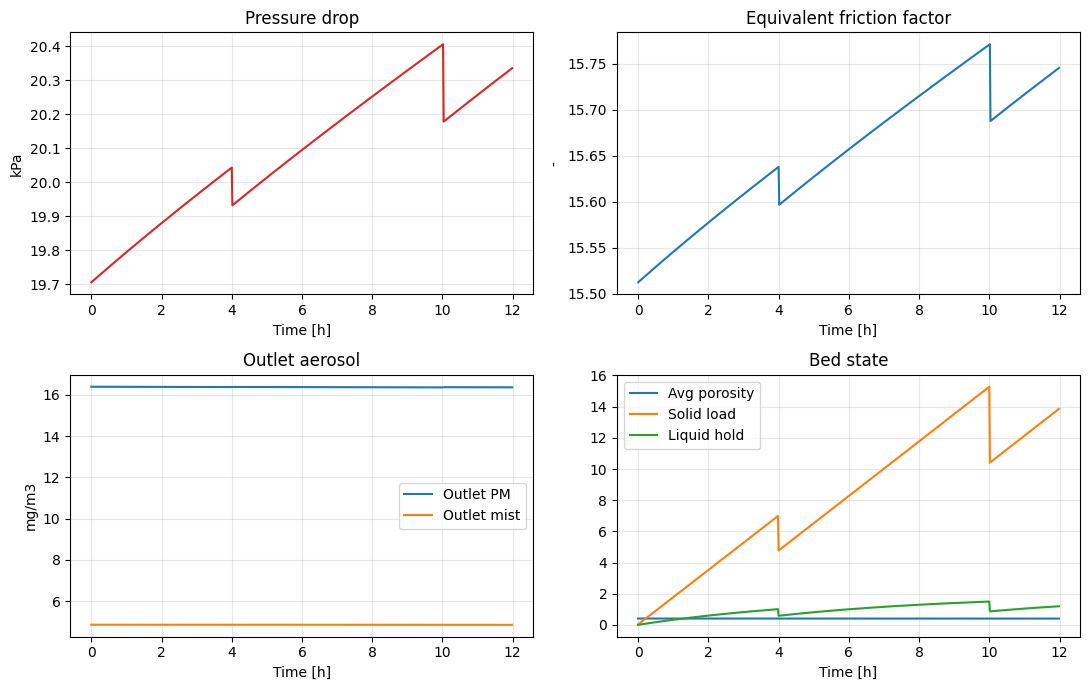

In [2]:
scenario = make_default_scenario()
sim = GuardBedSimulator(scenario)
history = sim.simulate(hours=12.0, dt_s=60.0)
labeled = add_future_labels(history, horizon_steps=60)

display(history_summary(history))
display(final_state_summary(history).to_frame(name='final_state'))
display(labeled[['time_h', 'deltaP_kPa', 'deltaP_future_kPa', 'friction_factor', 'friction_factor_future']].head(10))

fig, _ = plot_history(history)
plt.show()
plt.close(fig)

## Full dataset generation

This cell generates `100` scenarios and writes only `test.csv`.

In [3]:
dataset = generate_dataset(
    n_samples=100,
    simulation_hours=12.0,
    dt_s=60.0,
    horizon_h=1.0,
    seed=42,
    output_csv=OUTPUT_CSV,
)

print(f'Saved dataset to {OUTPUT_CSV.resolve()}')
print(f'Dataset shape: {dataset.shape}')
print(f"Unique sample_id count: {dataset['sample_id'].nunique()}")

preview_cols = [
    'sample_id',
    'time_h',
    'flow_mol_s',
    'P_in_kPa',
    'RH_in',
    'PM_inlet_mg_m3',
    'deltaP_kPa',
    'deltaP_future_kPa',
    'friction_factor',
    'friction_factor_future',
    'avg_porosity',
]

display(dataset[preview_cols].head(10))
display(dataset[preview_cols].describe(include='all'))

Saved dataset to C:\Users\junhyun111\Desktop\psa\preprocessing\test.csv
Dataset shape: (66000, 49)
Unique sample_id count: 100


,sample_id,time_h,flow_mol_s,P_in_kPa,RH_in,PM_inlet_mg_m3,deltaP_kPa,deltaP_future_kPa,friction_factor,friction_factor_future,avg_porosity
0,1,0.000000,634.918854,105.988933,0.592602,16.970088,65.988933,65.988933,11.210079,11.025262,0.393287
1,1,0.016667,634.918854,105.988933,0.592602,16.970088,65.988933,65.988933,11.206243,11.022458,0.393258
2,1,0.033333,634.918854,105.988933,0.592602,16.970088,65.988933,65.988933,11.202614,11.019661,0.393229
3,1,0.050000,634.918854,105.988933,0.592602,16.970088,65.988933,65.988933,11.199281,11.016873,0.393200
4,1,0.066667,634.918854,105.988933,0.592602,16.970088,65.988933,65.988933,11.195959,11.014091,0.393171
5,1,0.083333,634.918854,105.988933,0.592602,16.970088,65.988933,65.988933,11.192647,11.011318,0.393142
6,1,0.100000,634.918854,105.988933,0.592602,16.970088,65.988933,65.988933,11.189346,11.008551,0.393114
7,1,0.116667,634.918854,105.988933,0.592602,16.970088,65.988933,65.988933,11.186056,11.005792,0.393085
8,1,0.133333,634.918854,105.988933,0.592602,16.970088,65.988933,65.988933,11.182776,11.003041,0.393057
9,1,0.150000,634.918854,105.988933,0.592602,16.970088,65.988933,65.988933,11.179507,11.000297,0.393029


,sample_id,time_h,flow_mol_s,P_in_kPa,RH_in,PM_inlet_mg_m3,deltaP_kPa,deltaP_future_kPa,friction_factor,friction_factor_future,avg_porosity
count,66000.000000,66000.000000,66000.000000,66000.000000,66000.000000,66000.000000,66000.000000,66000.000000,66000.000000,66000.000000,66000.000000
mean,50.500000,5.491667,599.342902,104.141742,0.776433,23.090545,28.508732,28.596189,15.071032,15.086921,0.404649
std,28.866289,3.175447,101.848787,3.628025,0.127702,8.122400,20.187340,20.218888,3.348467,3.368652,0.022377
min,1.000000,0.000000,425.303536,98.041739,0.556488,8.080367,4.632973,4.647628,5.382210,5.338217,0.361491
25%,25.750000,2.745833,505.023226,101.054944,0.670722,17.003846,12.297290,12.315011,13.440856,13.460535,0.386952
50%,50.500000,5.491667,608.047747,103.658060,0.776298,22.868646,19.727150,19.795976,15.659201,15.681601,0.403224
75%,75.250000,8.237500,693.239025,106.772965,0.886795,28.878466,40.358581,40.623494,17.094566,17.119255,0.425602
max,100.000000,10.983333,756.744679,111.770157,0.979641,41.647199,70.058179,70.058179,21.502676,21.552001,0.448121
